# Classic VAE

## Imports

In [1]:
import sys
import os
from pathlib import Path

# Add project root to Python path
project_root = Path().resolve().parent
sys.path.insert(0, str(project_root))
os.environ["ENABLE_PJRT_COMPATIBILITY"] = "1"


from model import ClassicVAE
from train import ClassicVAE_trainer
from utils import image_to_jax1d, jax_collate_fn, plot_image

In [2]:
import jax
import jax.numpy as jnp
import jax.random as jr
from flax import nnx
import optax
import pcax
import matplotlib.pyplot as plt

os.environ['JAX_PLATFORMS'] = 'cpu'

from torch.utils.data import DataLoader
from torchvision.datasets import MNIST

import seaborn as sns
import pandas as pd
import numpy as np
from scipy.stats import multivariate_normal

## Training model

In [3]:
train_dataset = MNIST(root = "./../data", train = True, download = True, transform = image_to_jax1d)
test_dataset = MNIST(root = "./../data", train = False, download = True, transform = image_to_jax1d)

train_data_loader = DataLoader(train_dataset, batch_size = 128, shuffle = True, collate_fn = jax_collate_fn)
test_data_loader = DataLoader(test_dataset, batch_size = 128, shuffle = True, collate_fn = jax_collate_fn)

In [4]:
in_dim = 28*28
latent_dim = 16
hidden_dim = 256
rngs = nnx.Rngs(0)
learning_rate = 0.001
epochs = 20

### Linear Model

In [5]:
model_lin = ClassicVAE(in_dim = in_dim, latent_dim = latent_dim, hidden_dim = hidden_dim, rngs = rngs, arch = "linear")
optimizer_lin = nnx.Optimizer(model_lin, optax.adam(learning_rate), wrt = nnx.Param)
trainer_lin = ClassicVAE_trainer(model_lin, optimizer_lin)

In [6]:
train_history_lin, eval_history_lin = trainer_lin.train(epochs, train_data_loader, test_data_loader)

Training: 100%|██████████| 20/20 [09:55<00:00, 29.77s/it]


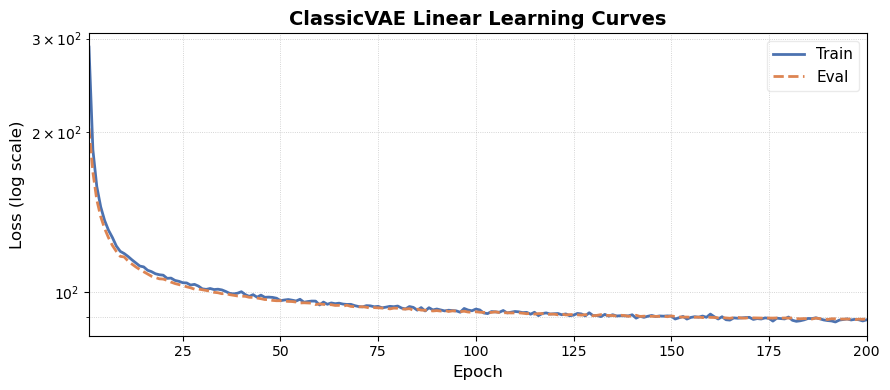

In [7]:
fig, ax = plt.subplots(figsize=(9, 4))

epochs_range = range(1, len(train_history_lin) + 1)

ax.plot(epochs_range, train_history_lin, color="#4C72B0", linewidth=2, label="Train")
ax.plot(epochs_range, eval_history_lin,  color="#DD8452", linewidth=2, linestyle="--", label="Eval")

ax.set_yscale("log")
ax.set_xlabel("Epoch", fontsize=12)
ax.set_ylabel("Loss (log scale)", fontsize=12)
ax.set_title("ClassicVAE Linear Learning Curves", fontsize=14, fontweight="bold")
ax.legend(fontsize=11, framealpha=0.4)
ax.grid(True, which="both", linestyle=":", linewidth=0.6, alpha=0.7)
ax.set_xlim(1, len(train_history_lin))

fig.tight_layout()
plt.show()

### Convolutional Model

In [8]:
model_conv = ClassicVAE(in_dim = in_dim, latent_dim = latent_dim, hidden_dim = hidden_dim, rngs = rngs, arch = "conv")
optimizer_conv = nnx.Optimizer(model_conv, optax.adam(learning_rate), wrt = nnx.Param)
trainer_conv = ClassicVAE_trainer(model_conv, optimizer_conv)

In [9]:
train_history_conv, eval_history_conv = trainer_conv.train(epochs, train_data_loader, test_data_loader)

Training: 100%|██████████| 20/20 [13:14<00:00, 39.70s/it]


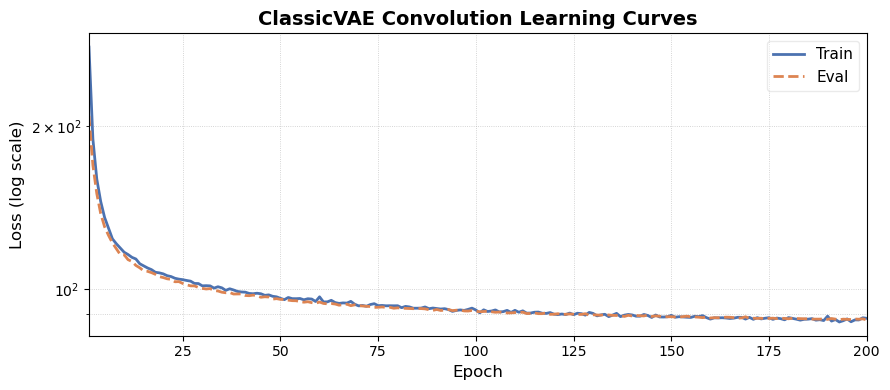

In [10]:
fig, ax = plt.subplots(figsize=(9, 4))

epochs_range = range(1, len(train_history_conv) + 1)

ax.plot(epochs_range, train_history_conv, color="#4C72B0", linewidth=2, label="Train")
ax.plot(epochs_range, eval_history_conv,  color="#DD8452", linewidth=2, linestyle="--", label="Eval")

ax.set_yscale("log")
ax.set_xlabel("Epoch", fontsize=12)
ax.set_ylabel("Loss (log scale)", fontsize=12)
ax.set_title("ClassicVAE Convolution Learning Curves", fontsize=14, fontweight="bold")
ax.legend(fontsize=11, framealpha=0.4)
ax.grid(True, which="both", linestyle=":", linewidth=0.6, alpha=0.7)
ax.set_xlim(1, len(train_history_conv))

fig.tight_layout()
plt.show()

## Reconstruction test

In [11]:
x = next(iter(train_data_loader))[0][:5]
keys = jr.split(jr.PRNGKey(0), 5)
x_lin = jax.vmap(lambda xi, k: model_lin(xi, k))(x, keys)
x_conv = jax.vmap(lambda xi, k: model_conv(xi, k))(x, keys)

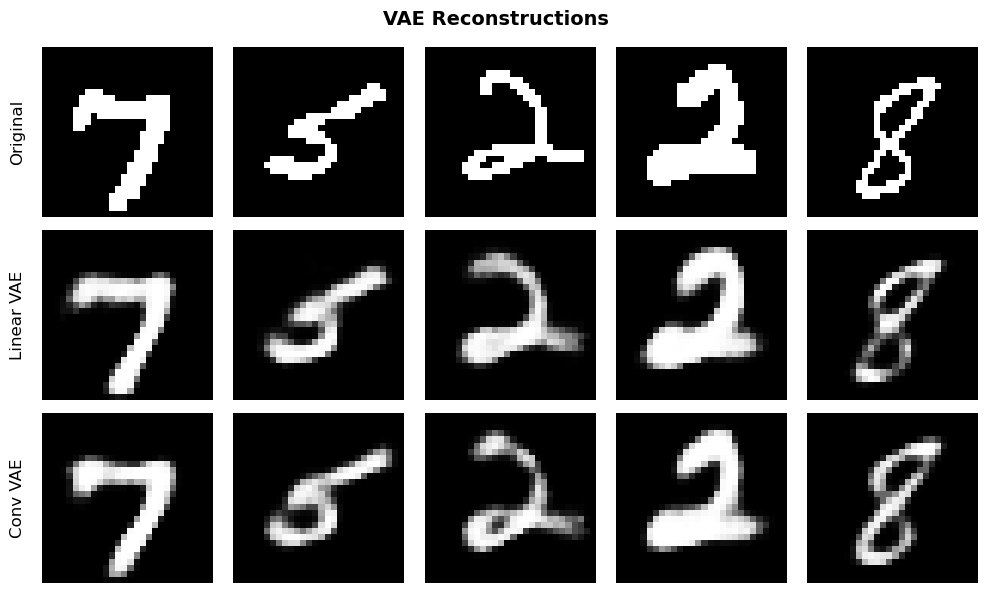

In [12]:
fig, axes = plt.subplots(3, 5, figsize=(10, 6))

row_labels = ["Original", "Linear VAE", "Conv VAE"]
rows = [x, x_lin, x_conv]

for row_idx, (label, row_data) in enumerate(zip(row_labels, rows)):
    for col_idx in range(5):
        ax = axes[row_idx, col_idx]
        plot_image(row_data[col_idx], ax=ax)
        ax.axis("off")
    axes[row_idx, 0].text(
        -0.1, 0.5, label,
        transform=axes[row_idx, 0].transAxes,
        fontsize=12, va="center", ha="right", rotation=90
    )

fig.suptitle("VAE Reconstructions", fontsize=14, fontweight="bold")
fig.tight_layout()
plt.show()

## Image generation

In [19]:
keys = jr.split(jr.PRNGKey(0), 5)
gen_lin  = jnp.stack([model_lin.generate_mean(k)  for k in keys])
gen_conv = jnp.stack([model_conv.generate_mean(k) for k in keys])

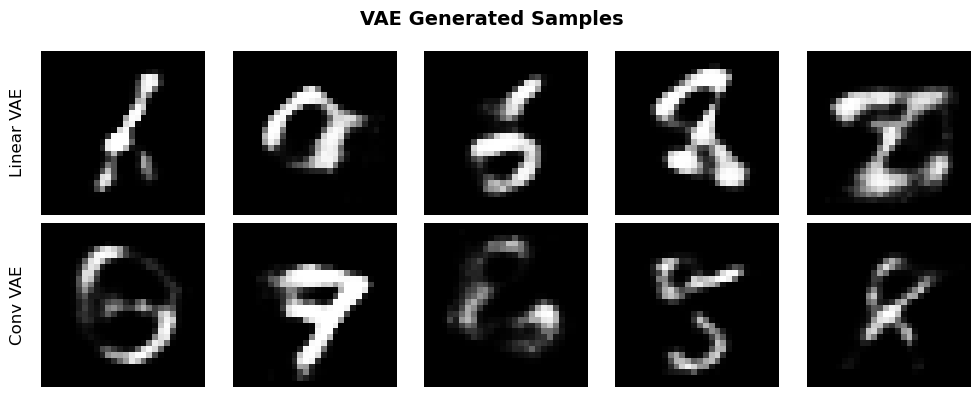

In [20]:
fig, axes = plt.subplots(2, 5, figsize=(10, 4))

row_labels = ["Linear VAE", "Conv VAE"]
rows = [gen_lin, gen_conv]

for row_idx, (label, row_data) in enumerate(zip(row_labels, rows)):
    for col_idx in range(5):
        ax = axes[row_idx, col_idx]
        plot_image(row_data[col_idx], ax=ax)
        ax.axis("off")
    axes[row_idx, 0].text(
        -0.1, 0.5, label,
        transform=axes[row_idx, 0].transAxes,
        fontsize=12, va="center", ha="right", rotation=90
    )

fig.suptitle("VAE Generated Samples", fontsize=14, fontweight="bold")
fig.tight_layout()
plt.show()

## Visualization of latent space

In [15]:
x = jnp.concatenate([batch[0] for batch in train_data_loader], axis=0)
labels = jnp.concatenate([batch[1] for batch in train_data_loader], axis=0)

In [16]:
keys = jr.split(jr.PRNGKey(0), x.shape[0])
z_lin = jax.vmap(model_lin.encode)(x, keys)
z_conv = jax.vmap(model_conv.encode)(x, keys)

In [17]:
state_lin = pcax.fit(z_lin, n_components=2)
z_lin_pca = pcax.transform(state_lin, z_lin)

state_conv = pcax.fit(z_conv, n_components=2)
z_conv_pca = pcax.transform(state_conv, z_conv)

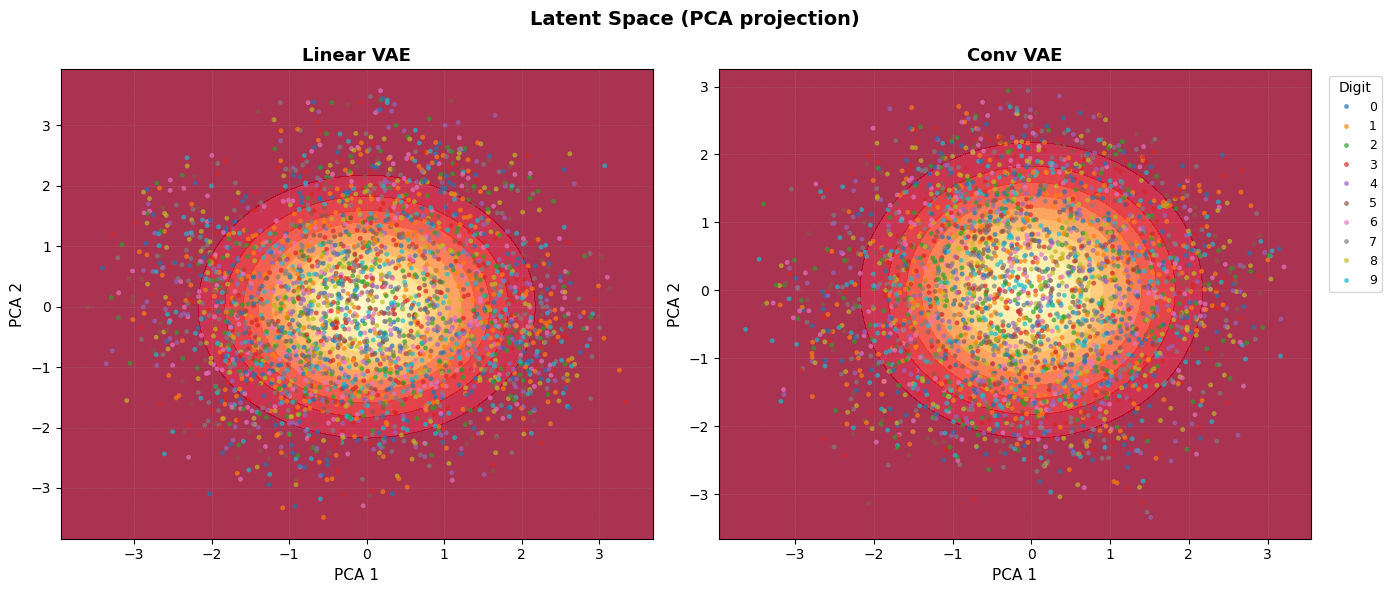

In [18]:
N_SCATTER = 3000

def make_df(z_pca, labels, n=N_SCATTER):
    idx = np.random.choice(len(z_pca), size=n, replace=False)
    return pd.DataFrame({
        "PCA 1": np.array(z_pca[idx, 0]),
        "PCA 2": np.array(z_pca[idx, 1]),
        "Digit": np.array(labels[idx]).astype(str),
    })

df_lin  = make_df(z_lin_pca,  labels)
df_conv = make_df(z_conv_pca, labels)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

palette = sns.color_palette("tab10", 10)
prior = multivariate_normal(mean=[0, 0], cov=np.eye(2))

for ax, df, title in zip(axes, [df_lin, df_conv], ["Linear VAE", "Conv VAE"]):
    x_min, x_max = df["PCA 1"].min(), df["PCA 1"].max()
    y_min, y_max = df["PCA 2"].min(), df["PCA 2"].max()
    margin_x, margin_y = (x_max - x_min) * 0.05, (y_max - y_min) * 0.05
    xx, yy = np.meshgrid(
        np.linspace(x_min - margin_x, x_max + margin_x, 300),
        np.linspace(y_min - margin_y, y_max + margin_y, 300),
    )
    zz = prior.pdf(np.stack([xx, yy], axis=-1))

    cf = ax.contourf(xx, yy, zz, levels=12, cmap="YlOrRd_r", alpha=0.8)
    # Removed colorbar as requested

    sns.scatterplot(
        data=df, x="PCA 1", y="PCA 2", hue="Digit",
        palette=palette, alpha=0.7, s=12, linewidth=0,
        hue_order=[str(i) for i in range(10)],
        ax=ax, legend=(ax == axes[1]),
    )

    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.set_xlabel("PCA 1", fontsize=11)
    ax.set_ylabel("PCA 2", fontsize=11)
    ax.grid(True, linestyle=":", linewidth=0.5, alpha=0.4)

axes[1].legend(title="Digit", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=9)
fig.suptitle("Latent Space (PCA projection)", fontsize=14, fontweight="bold")
fig.tight_layout()
plt.show()